# Разведочный анализ данных 

## Предварительная настройка

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
palette = [
    "#264653", 
    "#2a9d8f", 
    "#e9c46a", 
    "#f4a261", 
    "#e76f51", 
    "#8ab17d", 
    "#b5179e"
]

## Постановка задачи

Задача состоит в прогнозировании РТО на февраль для сети магазинов пятерочка. 

Для оценки качества предсказаний будет использоваться функция следующего вида: 

$$
\text{MAPE} = 100*\frac{1}{n}*\sum_{i=1}^n
\lvert 
\frac{y_{\text{pred}_i} - y_{\text{true}_i}}{y_{\text{true}_i}}
\rvert
$$

$$
\text{score} = 100 - \text{min}(\text{MAPE}, 100)
$$

Из описания датасета:

| Название колонки | Тип данных | Описание |
| :--- | :--- | :--- |
| **store_id** | `int64` | Уникальный идентификатор магазина |
| **year** / **month** | `int64` | Год и месяц наблюдения |
| **rto** | `float64` | **Целевая переменная:** Розничный товарооборот за месяц |
| **avg_items** / **avg_promo_items**| `float64` | Среднее кол-во товаров / промо-товаров в одном чеке |
| **avg_cancels** | `float64` | Среднее количество отмен чеков |
| **working_hours** | `float64` | Количество рабочих часов магазина в день |
| **opening_date_cat** | `object` | Категория даты открытия магазина |
| **store_area_cat** | `object` | Категория торговой площади |
| **city** / **region** | `object` | Населенный пункт и регион РФ |
| **population** / **households** | `int64` | Численность населения и кол-во домохозяйств вокруг |
| **foot_traffic** / **car_traffic** | `int64` | Пешеходный и автомобильный трафик в час |
| **marketplaces_100m** | `int64` | Кол-во маркетплейсов, доставок и постаматов в радиусе 100м |
| **pharmacy_300m** / **schools_300m** | `int64` | Кол-во аптек/мед.учреждений и школ в радиусе 300м |
| **stops_300m** | `int64` | Количество остановок общественного транспорта в радиусе 300м |
| **grocery_500m** / **pyaterochka_500m**| `int64` | Кол-во продуктовых конкурентов и других Пятёрочек в радиусе 500м |
| **cash_registers** | `int64` | Количество касс в магазине |
| **alcohol_license** | `int64` | Флаг наличия алкогольной лицензии (0 или 1) |

In [14]:
def get_score(y_true: np.ndarray, predictions: np.ndarray) -> tuple:
    eps_cons = 1e-8
    mape = 100 * np.mean(
        np.abs((predictions - y_true) / np.maximum(y_true, eps_cons))
    )
    score = 100 * ((100 - min(mape, 100)) / 100) ** 2
    return mape, score

In [15]:
rename_dict = {
    "new_id": "store_id",
    "Год": "year",
    "Месяц": "month",
    "Среднее количество промо товаров в чеке": "avg_promo_items",
    "Среднее количество товаров в чеке": "avg_items",
    "Среднее количество отмен": "avg_cancels",
    "Рабочие часы в день": "working_hours",
    "Дата открытия, категориальный": "opening_date_cat",
    "Торговая площадь, категориальный": "store_area_cat",
    "Населенный пункт": "city",
    "Регион": "region",
    "Численность населения": "population",
    "Количество домохозяйств": "households",
    "Трафик пеший, в час": "foot_traffic",
    "Трафик авто, в час": "car_traffic",
    "Маркетплейсы, доставки, постаматы (100 м)": "marketplaces_100m",
    "Медицинские уч. и аптеки (300 м)": "pharmacy_300m",
    "Школы (300 м)": "schools_300m",
    "Остановки (300 м)": "stops_300m",
    "Продуктовые магазины (500 м)": "grocery_500m",
    "Пятерочки (500 м)": "pyaterochka_500m",
    "Количество касс": "cash_registers",
    "Флаг алкогольной лицензии": "alcohol_license",
    "РТО": "rto"
}

## EDA

In [16]:
df = pd.read_csv("train_2.csv")
df = df.rename(columns=rename_dict)
df.sample(5)

,store_id,year,month,avg_promo_items,avg_items,avg_cancels,working_hours,opening_date_cat,store_area_cat,city,...,car_traffic,marketplaces_100m,pharmacy_300m,schools_300m,stops_300m,grocery_500m,pyaterochka_500m,cash_registers,alcohol_license,rto
484887,21734,2023,6,0.68,4.20,25.0,15.0,Средний по возрасту,Средний,Новосибирск г,...,141,2,0,2,0,6,1,6,1,6.773911e+07
24898,1117,2023,8,0.96,5.42,1.0,13.0,Средний по возрасту,Средний,Валуйки г,...,121,0,7,0,0,5,1,5,1,8.401446e+07
113138,5101,2023,6,0.77,3.82,18.0,13.0,Новый,Маленький,Самара г,...,151,3,4,1,2,9,5,4,1,3.158411e+07
156380,7038,2024,8,0.86,4.53,794.0,17.0,Открыт давно,Очень большой,Пермь г,...,544,3,4,1,4,4,1,10,1,8.731719e+07
405388,18148,2023,11,1.01,4.79,1508.0,12.0,Открыт давно,Очень большой,Москва г,...,40,6,10,1,19,6,3,15,1,3.267445e+08


In [17]:
print(f"Размер датасета: {df.shape[0]}")
print(f"Количество колонок: {df.shape[1]}")
print(f"Наличие дубликатов: {df.duplicated().any()}\n")
print(f"Наличие пропусков:\n{df.isna().sum().sort_values(ascending=False)}")

Размер датасета: 485082
Количество колонок: 24
Наличие дубликатов: False

Наличие пропусков:
store_id             0
year                 0
month                0
avg_promo_items      0
avg_items            0
avg_cancels          0
working_hours        0
opening_date_cat     0
store_area_cat       0
city                 0
region               0
population           0
households           0
foot_traffic         0
car_traffic          0
marketplaces_100m    0
pharmacy_300m        0
schools_300m         0
stops_300m           0
grocery_500m         0
pyaterochka_500m     0
cash_registers       0
alcohol_license      0
rto                  0
dtype: int64


In [18]:
def get_stats(X):
    uniques = X.nunique()
    return pd.DataFrame({
        "Количество уникальных": uniques,
        "Доля": np.round(uniques / X.shape[0] * 100, 2),
        "Тип данных": X.dtypes
    }).sort_values(by="Доля", ascending=False)

In [19]:
get_stats(df).head(10)

,Количество уникальных,Доля,Тип данных
rto,485070,100.00,float64
store_id,18657,3.85,int64
population,17205,3.55,int64
households,7912,1.63,int64
city,3270,0.67,str
avg_cancels,2792,0.58,float64
car_traffic,1078,0.22,int64
avg_items,998,0.21,float64
foot_traffic,542,0.11,int64
avg_promo_items,279,0.06,float64


### Анализ целевой переменной

In [20]:
df_rto = df["rto"]
df_rto.describe ()

count    4.850820e+05
mean     8.853480e+07
std      4.824900e+07
min      1.179116e+06
25%      5.627279e+07
50%      7.521094e+07
75%      1.057677e+08
max      6.557204e+08
Name: rto, dtype: float64

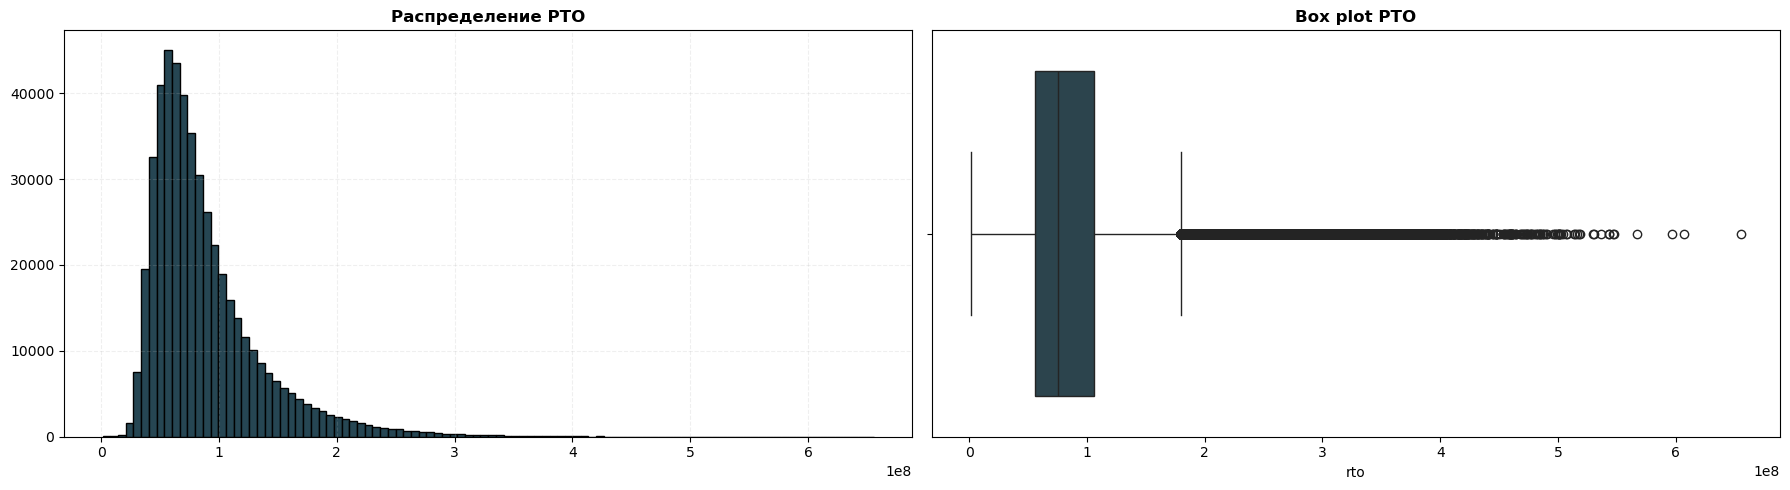

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

axes[0].hist(
    df_rto,
    bins=100,
    color=palette[0],
    edgecolor="black",
)
axes[0].set_title("Распределение РТО", weight="bold")
axes[0].grid(linestyle="--", alpha=0.2)

sns.boxplot(x=df_rto, color=palette[0], ax=axes[1])
axes[1].set_title("Box plot РТО", weight="bold")

plt.tight_layout()

### Анализ аномально высокой выручки

Изучим топ-1% магазинов по обороту, чтобы понять, что объединяет самые прибыльные точки.

In [22]:
rto_threshold_99 = df["rto"].quantile(0.99)
df_high_rto = df[df["rto"] > rto_threshold_99]

print(f"Порог 99-го квантиля: {np.round(rto_threshold_99, 2)} руб")
print(f"Количество записей в топ-1%: {len(df_high_rto)}")
df_high_rto.sample(3)

Порог 99-го квантиля: 265394753.81 руб
Количество записей в топ-1%: 4851


,store_id,year,month,avg_promo_items,avg_items,avg_cancels,working_hours,opening_date_cat,store_area_cat,city,...,car_traffic,marketplaces_100m,pharmacy_300m,schools_300m,stops_300m,grocery_500m,pyaterochka_500m,cash_registers,alcohol_license,rto
13657,618,2023,3,1.41,5.66,1410.0,13.0,Открыт давно,Очень большой,Москва г,...,102,3,0,2,4,1,0,16,1,3.457136e+08
119751,5387,2024,10,0.89,10.72,199.0,5.0,Средний по возрасту,Средний,Рыльск г,...,187,5,2,0,0,5,1,12,1,2.701478e+08
367319,16459,2024,8,1.33,8.31,1111.0,11.0,Новый,Большой,Каринское с,...,0,4,0,0,1,1,0,12,1,3.074777e+08


Проверим, как выручка в этих магазинах коррелирует с пешеходным трафиком. Это поможет понять, является ли высокий РТО следствием удачного расположения.

In [30]:
print("Топ-5 городов по количеству сверхприбыльных магазинов:")
print(df_high_rto["city"].value_counts().head())
print("\nРаспределение по размеру площади:")
print(df_high_rto["store_area_cat"].value_counts())
print("\nРаспределение по дате открытия:")
print(df_high_rto["opening_date_cat"].value_counts())

Топ-5 городов по количеству сверхприбыльных магазинов:
city
Москва г             1868
Санкт-Петербург г    1189
Балашиха г            114
Домодедово г           81
Раменское г            77
Name: count, dtype: int64

Распределение по размеру площади:
store_area_cat
Очень большой    2324
Большой          2158
Средний           332
Маленький          37
Name: count, dtype: int64

Распределение по дате открытия:
opening_date_cat
Открыт давно           2223
Средний по возрасту    1728
Новый                   900
Name: count, dtype: int64


Попробуем оценить зависимость РТО от трафика - возможно он полностью объясняет успех отдельных магазинов. В противном случае, скорее всего имеет место покупательная способность населения:

Хочу оценить зависимости от следуюзщего - working_hours, households, foot_traffic, grocery_500m. Сделай, перепиши введение.

**Выводы по анализу выбросов:**

1. Географически самые прибыльные магазины находятся в крупных городах: Москва и Санкт-Петербург. Это объясняется большим населением и высокой покупательной способностью. Это также подтверждается тем, что большая часть лучших магазинов имеет большой показатель количества домохозяйств рядом.
2. Почти все магазины с высокой выручкой оказались большими или очень большими по площади. Маленькие магазины почти не попадают в эту категорию.
3. В основном такие магазины работают давно или являются средними по возрасту. 
4. Магазины, работающие от 10 часов в сутки показывают наибольше доходы. 
5. Наличие конкурентов рядом влияет на прибыль только при аномально высоких значениях. Это ещё раз свидетельствует о том, что топовые магазины расположены в лоакациях с высоким покупательским спросом.

Таким образом, получаем карточку магазина с большой прибылью: крупный по площади супермаркет, находящийся в Москве или Питере с наработанной и обеспеченной клиентской базой. 

**Дополнительно**

- в данных присутствуют выбросы - например, магазины, которые работают больше 36 часов в сутки. Скорее всего, это связано с ошибкой при загрузке информации.
- Некоторые магазины имеют до 14 конкурентов рядом: скорее всего, это магазины, расположенные рядом или непосредственно в крупных ТЦ.